In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('./parameterTests/MLPKAN_res.csv')

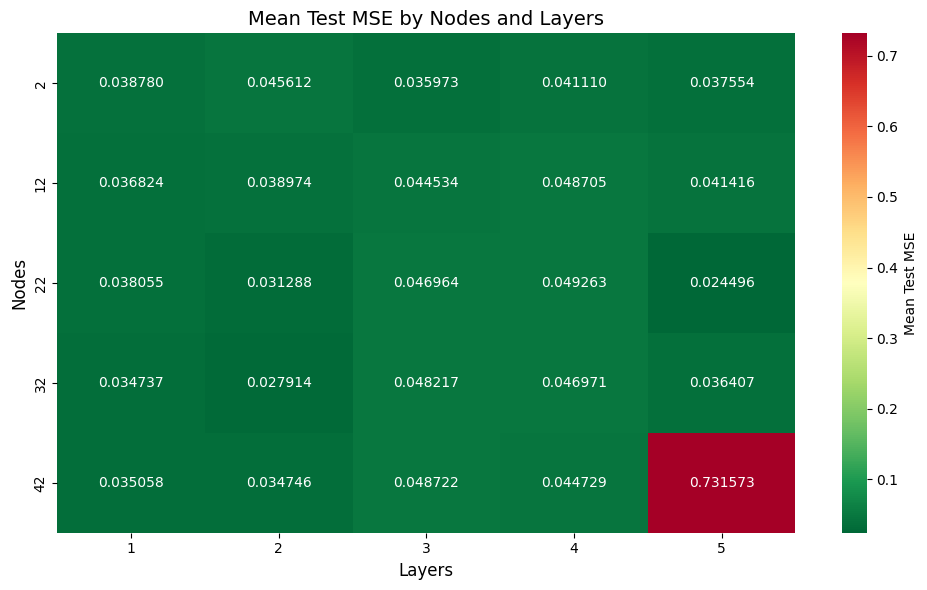

In [3]:

mean_mse = df.groupby(['Layers', 'Nodes'])['test MSE'].mean().reset_index()
pivot_table = mean_mse.pivot(index='Nodes', columns='Layers', values='test MSE').iloc[:5, :]  # Limit to first 5 layers
# Create heatmap
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt='.6f', cmap='RdYlGn_r', cbar_kws={'label': 'Mean Test MSE'}, ax=ax)
ax.set_xlabel('Layers', fontsize=12)
ax.set_ylabel('Nodes', fontsize=12)
ax.set_title('Mean Test MSE by Nodes and Layers', fontsize=14)
plt.tight_layout()
plt.show()

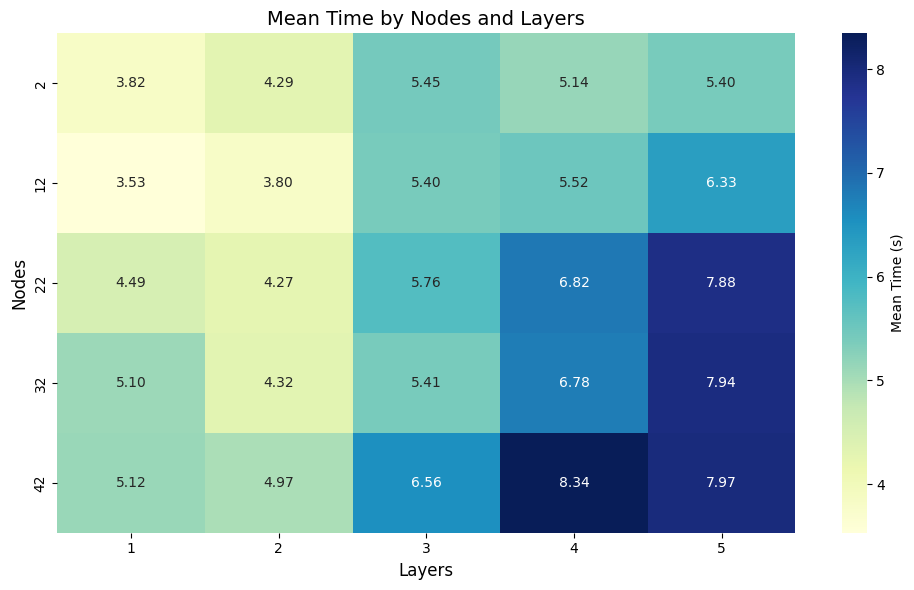

In [4]:
mean_time = df[(df['R2 Score (Test)']>0.999)].groupby(['Layers', 'Nodes'])['time'].mean().reset_index()

pivot_time = mean_time.pivot(index='Nodes', columns='Layers', values='time').iloc[:5, :]
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot_time, annot=True, fmt='.2f', cmap='YlGnBu', cbar_kws={'label': 'Mean Time (s)'}, ax=ax)
ax.set_xlabel('Layers', fontsize=12)
ax.set_ylabel('Nodes', fontsize=12)
ax.set_title('Mean Time by Nodes and Layers', fontsize=14)
plt.tight_layout()
plt.show()


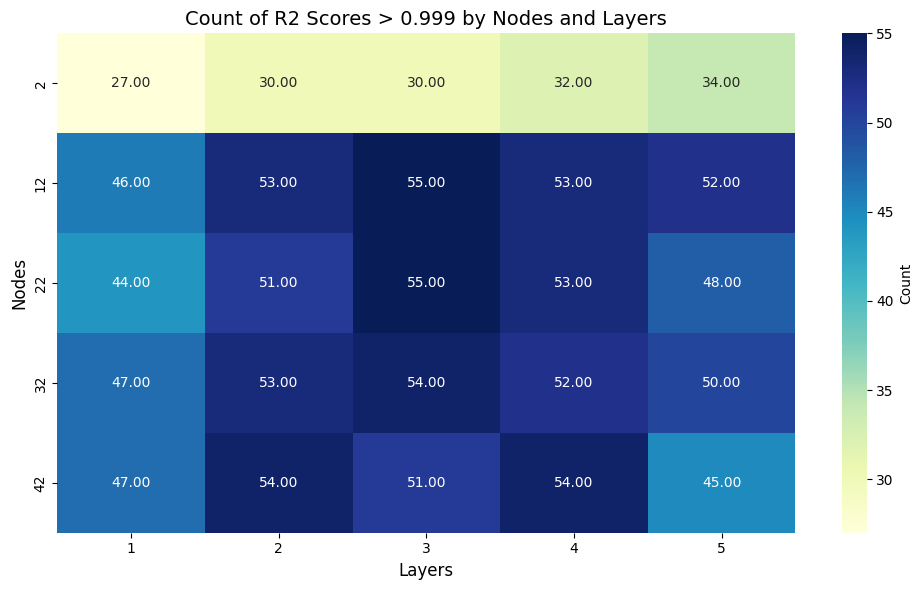

In [5]:
countR299 = df[df['R2 Score (Test)']>0.999].groupby(['Layers', 'Nodes'])['time'].count().reset_index()

pivot_time = countR299.pivot(index='Nodes', columns='Layers', values='time').iloc[:5, :]
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot_time, annot=True, fmt='.2f', cmap='YlGnBu', cbar_kws={'label': 'Count'}, ax=ax)
ax.set_xlabel('Layers', fontsize=12)
ax.set_ylabel('Nodes', fontsize=12)
ax.set_title('Count of R2 Scores > 0.999 by Nodes and Layers', fontsize=14)
plt.tight_layout()
plt.show()
